# Indoor Air Quality Prediction using LightGBM

This notebook implements a LightGBM model to predict Air Quality based on sensor data from Baqubah Teaching Hospital

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
file_path = "cleaned_dataset.csv"
df = pd.read_csv(file_path)

# Display basic info
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65518 entries, 0 to 65517
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ts           65518 non-null  object 
 1   CO2          65518 non-null  float64
 2   TVOC         65518 non-null  float64
 3   PM10         65518 non-null  float64
 4   PM2.5        65518 non-null  float64
 5   CO           65518 non-null  float64
 6   Air Quality  65518 non-null  float64
 7   LDR          65518 non-null  float64
 8   O3           65518 non-null  float64
 9   Temp         65518 non-null  float64
 10  Hum          65518 non-null  float64
dtypes: float64(10), object(1)
memory usage: 5.5+ MB
None


,ts,CO2,TVOC,PM10,PM2.5,CO,Air Quality,LDR,O3,Temp,Hum
0,2024-05-22 12:10:00,422.250000,15.250000,5.215000,0.290000,358.750000,41.750000,962.000000,521.750000,26.250000,41.675000
1,2024-05-22 12:15:00,422.333333,17.250000,5.762500,0.279583,360.250000,40.916667,962.000000,524.208333,26.116667,41.658333
2,2024-05-22 12:20:00,421.790476,18.395238,6.052429,0.286976,359.404762,40.785714,960.847619,524.788095,26.061905,41.807143
3,2024-05-22 12:25:00,421.247619,19.540476,6.342357,0.294369,358.559524,40.654762,959.695238,525.367857,26.007143,41.955952
4,2024-05-22 12:30:00,420.704762,20.685714,6.632286,0.301762,357.714286,40.523810,958.542857,525.947619,25.952381,42.104762


## 2. Data Preprocessing

In [3]:
# Convert Timestamp
df['ts'] = pd.to_datetime(df['ts'])

# Check for missing values
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
ts             0
CO2            0
TVOC           0
PM10           0
PM2.5          0
CO             0
Air Quality    0
LDR            0
O3             0
Temp           0
Hum            0
dtype: int64


In [4]:
# Sort by timestamp and set as index
df = df.sort_values('ts')
df.set_index('ts', inplace=True)

# Handle any remaining missing values with forward fill
df = df.ffill().bfill()

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
CO2            0
TVOC           0
PM10           0
PM2.5          0
CO             0
Air Quality    0
LDR            0
O3             0
Temp           0
Hum            0
dtype: int64


## 3. Feature Selection

In [5]:
# Define base features (excluding eCO2 which was dropped from cleaned dataset)
base_features = ['CO2', 'TVOC', 'PM10', 'Air Quality', 'CO', 'O3', 'Temp', 'Hum', 'LDR']
target = 'PM2.5'

print(f"Base features: {base_features}")
print(f"Target: {target}")

Base features: ['CO2', 'TVOC', 'PM10', 'Air Quality', 'CO', 'O3', 'Temp', 'Hum', 'LDR']
Target: PM2.5


## 4. Temporal Feature Engineering

Create lag features, rolling statistics, and time-based features for time-series forecasting.

In [6]:
# Create temporal features for time-series modeling
def create_temporal_features(df, target_col, base_features):
    """
    Create lag features, rolling statistics, and time-based features
    for time-series forecasting with tree-based models.
    """
    df_features = df.copy()
    
    # Time-based features
    df_features['hour'] = df_features.index.hour
    df_features['day_of_week'] = df_features.index.dayofweek
    df_features['month'] = df_features.index.month
    df_features['is_weekend'] = (df_features.index.dayofweek >= 5).astype(int)
    
    # Lag features for target variable (PM2.5)
    for lag in [1, 2, 3, 6, 12, 24]:
        df_features[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    
    # Lag features for key variables
    key_vars = ['CO2', 'TVOC', 'PM10']
    for var in key_vars:
        if var in df.columns:
            for lag in [1, 3, 6]:
                df_features[f'{var}_lag_{lag}'] = df[var].shift(lag)
    
    # Rolling statistics for target
    # Shift ALL of them by 1 to avoid leakage
    for window in [3, 6, 12, 24]:
        df_features[f'{target_col}_rolling_mean_{window}'] = df[target_col].shift(1).rolling(window=window).mean()

    for window in [6, 12, 24]:
        df_features[f'{target_col}_rolling_std_{window}'] = df[target_col].shift(1).rolling(window=window).std()

    for window in [12, 24]:
        df_features[f'{target_col}_rolling_min_{window}'] = df[target_col].shift(1).rolling(window=window).min()
        df_features[f'{target_col}_rolling_max_{window}'] = df[target_col].shift(1).rolling(window=window).max()
    
    # Drop rows with NaN values created by lag/rolling features
    df_features = df_features.dropna()
    
    return df_features

# Create temporal features
df_temporal = create_temporal_features(df, target, base_features)

print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after temporal features: {df_temporal.shape}")
print(f"\nNew features created: {df_temporal.shape[1] - df.shape[1]}")
print(f"\nFirst few temporal feature names:")
print([col for col in df_temporal.columns if col not in df.columns][:10])

Original dataset shape: (65518, 10)
Dataset shape after temporal features: (65494, 40)

New features created: 30

First few temporal feature names:
['hour', 'day_of_week', 'month', 'is_weekend', 'PM2.5_lag_1', 'PM2.5_lag_2', 'PM2.5_lag_3', 'PM2.5_lag_6', 'PM2.5_lag_12', 'PM2.5_lag_24']


## 5. Split Train and Test

In [7]:
# Time-based train/test split (80/20)\n",
# # This preserves temporal order for time-series data\n",
split_idx = int(len(df_temporal) * 0.8)
# Prepare features and target
# CRITICAL FIX: Only use temporal features (lags, rolling, time info)
# We exclude the original columns (like 'PM10', 'CO2') because they represent the CURRENT time step
# In a real forecast, we wouldn't know them yet
temporal_cols = [col for col in df_temporal.columns if '_lag_' in col or '_rolling_' in col or col in ['hour', 'day_of_week', 'month', 'is_weekend']]
X = df_temporal[temporal_cols]
y = df_temporal[target]

# Split data\n"
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Features used: {list(X_train.columns)}")

Training set size: 52395
Test set size: 13099
Number of features: 30
Features used: ['hour', 'day_of_week', 'month', 'is_weekend', 'PM2.5_lag_1', 'PM2.5_lag_2', 'PM2.5_lag_3', 'PM2.5_lag_6', 'PM2.5_lag_12', 'PM2.5_lag_24', 'CO2_lag_1', 'CO2_lag_3', 'CO2_lag_6', 'TVOC_lag_1', 'TVOC_lag_3', 'TVOC_lag_6', 'PM10_lag_1', 'PM10_lag_3', 'PM10_lag_6', 'PM2.5_rolling_mean_3', 'PM2.5_rolling_mean_6', 'PM2.5_rolling_mean_12', 'PM2.5_rolling_mean_24', 'PM2.5_rolling_std_6', 'PM2.5_rolling_std_12', 'PM2.5_rolling_std_24', 'PM2.5_rolling_min_12', 'PM2.5_rolling_max_12', 'PM2.5_rolling_min_24', 'PM2.5_rolling_max_24']


## 6. Model Training (LightGBM)

In [8]:
import time

# Before training
start_time = time.time()

# Initialize LightGBM Regressor
model = lgb.LGBMRegressor(
            objective='regression',
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42
            )

# Train model
model.fit(X_train, y_train)
print("Model training complete.")

# After training
training_time = time.time() - start_time
print(f"LightGBM Training time: {training_time:.2f} seconds")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037312 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6671
[LightGBM] [Info] Number of data points in the train set: 52395, number of used features: 30
[LightGBM] [Info] Start training from score 87.581363
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

## 7. Evaluation

Mean Absolute Error (MAE): 13.8132
Root Mean Squared Error (RMSE): 18.1329
R-squared (R2): 0.7454


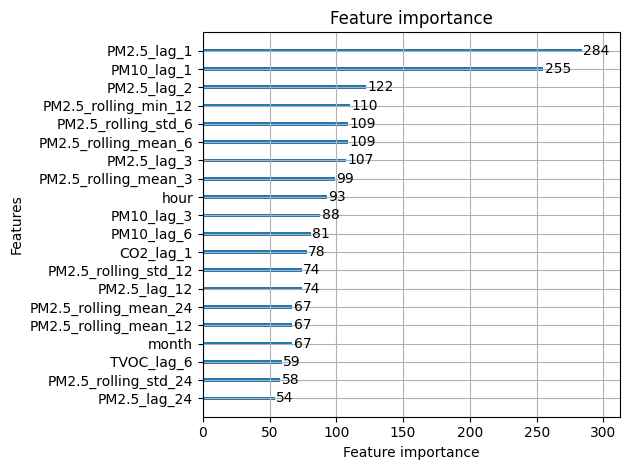

In [9]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Feature Importance
lgb.plot_importance(model, max_num_features=20)
plt.tight_layout()
plt.show()

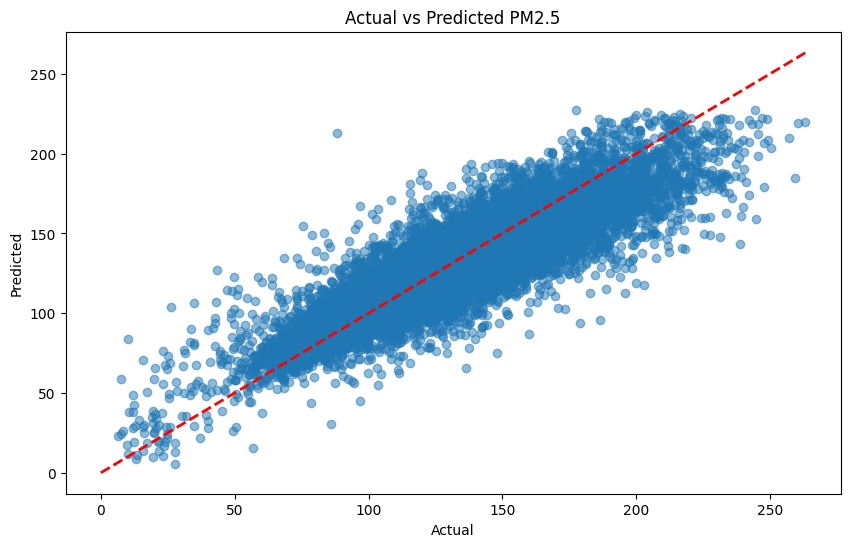

In [10]:
# Plot Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted PM2.5')
plt.show()

In [11]:
# Standardized Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mean_pm2_5 = df['PM2.5'].mean()
mape = mae/mean_pm2_5

print('Performance Metrics:')
print(f'MAPE: {mape:.4f}')
print(f'MSE:  {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE:  {mae:.4f}')
print(f'R2:   {r2:.4f}')

Performance Metrics:
MAPE: 0.1427
MSE:  328.8023
RMSE: 18.1329
MAE:  13.8132
R2:   0.7454


In [12]:
# Save the trained model\n",
# Option 1: Save as text file (LightGBM native format)\n",
model.booster_.save_model('lightgbm_model.txt')
print("Model saved as 'lightgbm_model.txt'")


Model saved as 'lightgbm_model.txt'
